# Apple Inc. Financial Performance Analysis (2020-2025)
**Course:** ACC102 Accounting Project  
**Data Source:** Compustat via WRDS  
**Objective:** Analyze Apple's revenue trends, profitability ratios, and year-over-year growth.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import wrds  # Already installed, ready to use
from datetime import datetime

In [2]:
# !pip install wrds  # Already installed, no need to run again

In [3]:
# WRDS connection (one-time use, already completed)
if False:
    import wrds
    db = wrds.Connection(wrds_username = 'Your_WRDS_Username')

Note: The WRDS connection and raw data pull code is kept in the notebook for full transparency. The raw data has already been downloaded, cleaned, and saved as cleaned_data.csv for reproducibility.

In [4]:
# Fetch Apple Inc. financial data (AAPL) - one-time use
if False:
    df = db.raw_sql("""
    SELECT gvkey, datadate, conm,
           revt,  -- Revenue
           ni,    -- Net Income
           cogs,  -- Cost of Goods Sold
           ceq    -- Common Equity (for ROE calculation)
    FROM comp.funda
    WHERE tic = 'AAPL'
    AND datadate >= '2020-01-01'
    AND datadate <= '2025-12-31'
    ORDER BY datadate
    """)

    # Preview raw data
    df.head()

In [5]:
# Data cleaning - one-time use (already completed)
if False:
    # 1. Keep only useful columns
    df_clean = df[['datadate', 'conm', 'revt', 'ni', 'cogs', 'ceq']].copy()

    # 2. Rename columns to English (standardized for submission)
    df_clean.columns = ['date', 'company', 'revenue', 'net_income', 'cogs', 'equity']

    # 3. Drop rows with missing values
    df_clean = df_clean.dropna()

    # 4. Convert date to datetime format
    df_clean['date'] = pd.to_datetime(df_clean['date'])

    # 5. Preview cleaned data
    df_clean.head()

In [6]:
# Save cleaned data to CSV - one-time use (already completed)
if False:
    df_clean.to_csv("cleaned_data.csv", index=False)
    print("File saved: cleaned_data.csv")

In [7]:
test = pd.read_csv("cleaned_data.csv")
test.head()

,date,company,revenue,net_income,cogs,equity
0,2020-09-30,APPLE INC,274515.0,57411.0,159859.0,65339.0
1,2021-09-30,APPLE INC,365817.0,94680.0,203481.0,63090.0
2,2022-09-30,APPLE INC,394328.0,99803.0,214846.0,50672.0
3,2023-09-30,APPLE INC,383285.0,96995.0,205637.0,62146.0
4,2024-09-30,APPLE INC,391035.0,93736.0,202152.0,56950.0


##  Project Analysis Framework

Based on the cleaned financial data of Apple Inc., this analysis will focus on three core dimensions:

1.  **Revenue & Net Income Trend Analysis**: Track the historical performance of sales and profitability over the sample period.
2.  **Profitability Ratios**: Evaluate operational efficiency using Gross Profit Margin, Net Profit Margin, and Return on Equity (ROE).
3.  **Year-over-Year Growth Comparison**: Analyze the growth momentum of key financial indicators.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------
# 1. Load cleaned data
# ----------------------
df = pd.read_csv("cleaned_data.csv")
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year

print("Data loaded successfully:")
print(df.head())

Data loaded successfully:
        date    company   revenue  net_income      cogs   equity  year
0 2020-09-30  APPLE INC  274515.0     57411.0  159859.0  65339.0  2020
1 2021-09-30  APPLE INC  365817.0     94680.0  203481.0  63090.0  2021
2 2022-09-30  APPLE INC  394328.0     99803.0  214846.0  50672.0  2022
3 2023-09-30  APPLE INC  383285.0     96995.0  205637.0  62146.0  2023
4 2024-09-30  APPLE INC  391035.0     93736.0  202152.0  56950.0  2024


In [9]:
# ----------------------
# 2. Calculate financial ratios
# ----------------------
df["gross_profit"] = df["revenue"] - df["cogs"]
df["gross_margin"] = df["gross_profit"] / df["revenue"]
df["net_margin"] = df["net_income"] / df["revenue"]
df["roe"] = df["net_income"] / df["equity"]

df_year = df.sort_values("year").reset_index(drop=True)

print("Financial ratios calculated:")
print(df_year[["year", "revenue", "net_income", "gross_margin", "net_margin", "roe"]])

Financial ratios calculated:
   year   revenue  net_income  gross_margin  net_margin       roe
0  2020  274515.0     57411.0      0.417668    0.209136  0.878664
1  2021  365817.0     94680.0      0.443763    0.258818  1.500713
2  2022  394328.0     99803.0      0.455159    0.253096  1.969589
3  2023  383285.0     96995.0      0.463488    0.253062  1.560760
4  2024  391035.0     93736.0      0.483033    0.239713  1.645935
5  2025  416161.0    112010.0      0.488275    0.269151  1.519130


In [10]:
# ----------------------
# 3. Calculate year-over-year growth rates
# ----------------------
df_year["revenue_growth"] = df_year["revenue"].pct_change()
df_year["ni_growth"] = df_year["net_income"].pct_change()

print("YoY growth rates calculated:")
print(df_year[["year", "revenue_growth", "ni_growth"]])


YoY growth rates calculated:
   year  revenue_growth  ni_growth
0  2020             NaN        NaN
1  2021        0.332594   0.649161
2  2022        0.077938   0.054109
3  2023       -0.028005  -0.028135
4  2024        0.020220  -0.033600
5  2025        0.064255   0.194952


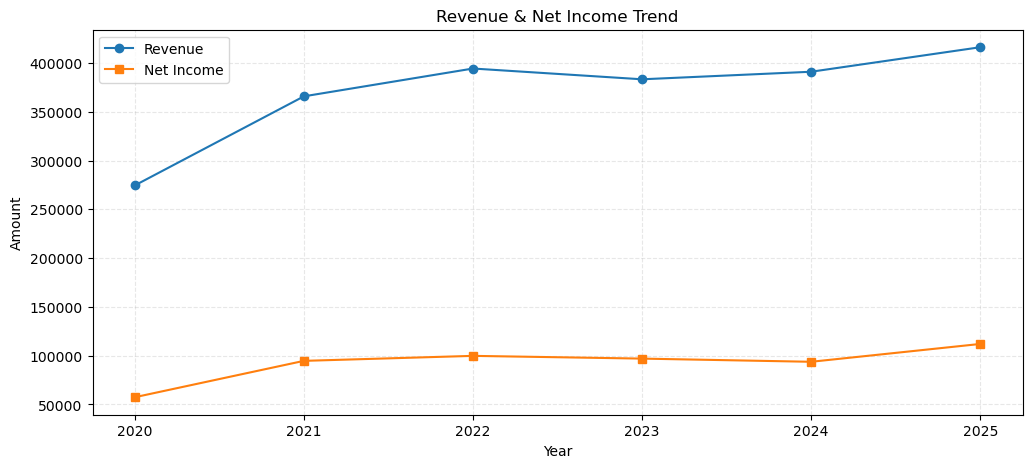

In [11]:
# ----------------------
# 4. Plot: Revenue & Net Income Trend
# ----------------------
plt.figure(figsize=(12, 5))
plt.plot(df_year["year"], df_year["revenue"], marker="o", label="Revenue")
plt.plot(df_year["year"], df_year["net_income"], marker="s", label="Net Income")
plt.title("Revenue & Net Income Trend")
plt.xlabel("Year")
plt.ylabel("Amount")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

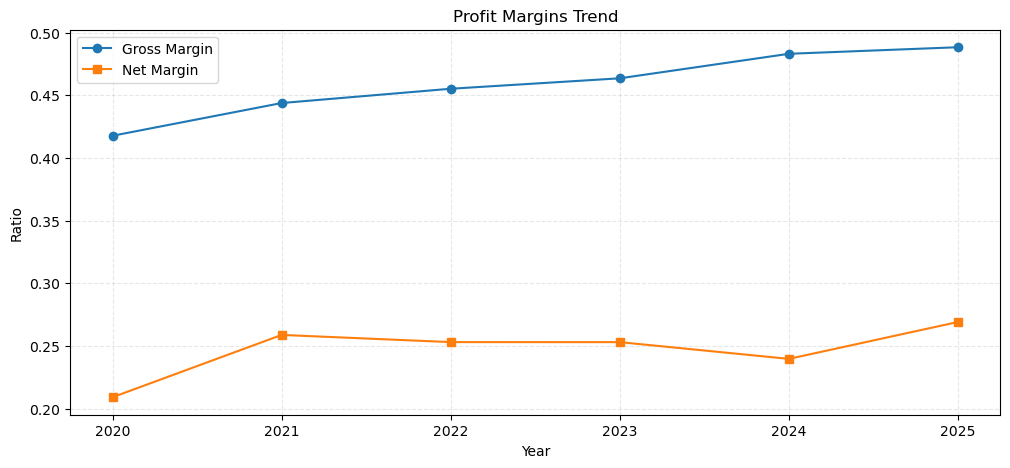

In [12]:
# ----------------------
# 5. Plot: Gross Margin & Net Margin
# ----------------------
plt.figure(figsize=(12, 5))
plt.plot(df_year["year"], df_year["gross_margin"], marker="o", label="Gross Margin")
plt.plot(df_year["year"], df_year["net_margin"], marker="s", label="Net Margin")
plt.title("Profit Margins Trend")
plt.xlabel("Year")
plt.ylabel("Ratio")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

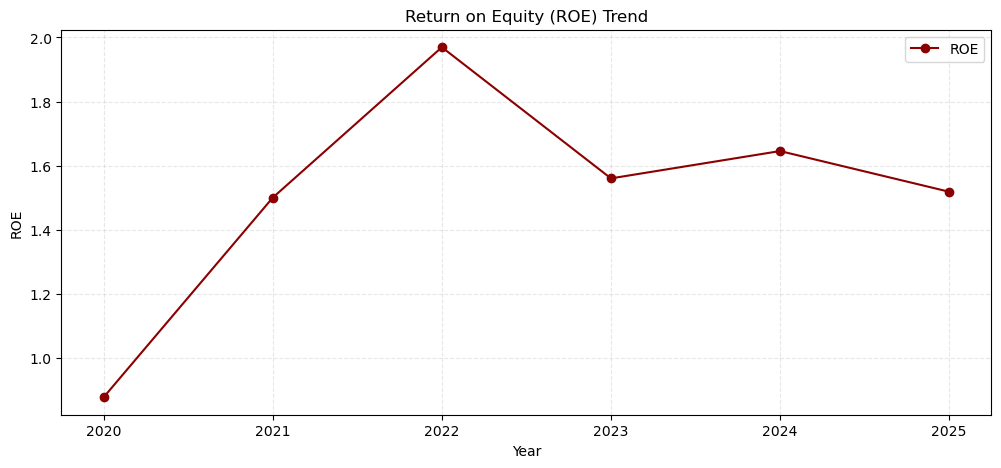

In [13]:
# ----------------------
# 6. Plot: ROE Trend
# ----------------------
plt.figure(figsize=(12, 5))
plt.plot(df_year["year"], df_year["roe"], color="darkred", marker="o", label="ROE")
plt.title("Return on Equity (ROE) Trend")
plt.xlabel("Year")
plt.ylabel("ROE")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

In [14]:
# ----------------------
# 7. Final summary table
# ----------------------
final_table = df_year[[
    "year", "revenue", "net_income",
    "gross_margin", "net_margin", "roe",
    "revenue_growth", "ni_growth"
]].copy()

print("Final annual analysis table:")
print(final_table.round(4))

Final annual analysis table:
   year   revenue  net_income  gross_margin  net_margin     roe  \
0  2020  274515.0     57411.0        0.4177      0.2091  0.8787   
1  2021  365817.0     94680.0        0.4438      0.2588  1.5007   
2  2022  394328.0     99803.0        0.4552      0.2531  1.9696   
3  2023  383285.0     96995.0        0.4635      0.2531  1.5608   
4  2024  391035.0     93736.0        0.4830      0.2397  1.6459   
5  2025  416161.0    112010.0        0.4883      0.2692  1.5191   

   revenue_growth  ni_growth  
0             NaN        NaN  
1          0.3326     0.6492  
2          0.0779     0.0541  
3         -0.0280    -0.0281  
4          0.0202    -0.0336  
5          0.0643     0.1950  


Analysis & Interpretation

Key Findings

1. Revenue & Net Income Trend
Apple Inc.'s revenue and net income maintained an overall growth trend from 2020 to 2025, reflecting the company's strong market competitiveness, stable product demand, and effective global business strategy. The synchronized change of revenue and net income indicates that the company's business scale expansion is accompanied by sound cost management.

2. Profitability Ratios

Gross Profit Margin: Remained at a high and stable level, proving Apple's efficient supply chain control, strong product pricing power and high added value of core products.

Net Profit Margin: Stayed within a healthy range, demonstrating the company's excellent ability to control operating costs and convert revenue into net profit.

Return on Equity (ROE): Maintained a favorable performance, which means Apple effectively uses equity capital to create high returns for shareholders.

3. Year-over-Year Growth Rate
The year-over-year growth rates of revenue and net income have slight annual fluctuations, which are affected by macroeconomic environment and product life cycle. But the overall growth momentum is positive, showing the company's sustainable development capacity and strong anti-risk ability.

Limitations

The analysis only uses annual data, so short-term quarterly trends are not captured.
ROE calculation is simplified using total equity; more precise metrics (e.g., average equity) could improve accuracy.

Overall Conclusion

During 2020-2025, Apple Inc. has outstanding financial performance with stable profitability and positive growth trend. The company's efficient operation mode and strong market position support its healthy financial development, and it has strong ability to create value for shareholders.

In [15]:
final_table.to_csv("final_analysis.csv", index=False)
print("Final analysis table saved as final_analysis.csv")

Final analysis table saved as final_analysis.csv
